## Prompt
> In Xtalpi VAST database, find 200 molecules with Mw under 400 Da having tetrazolic core and benzyl group (benzyl cannot have any other substituent - just CH2-Ph). LogP must be under 4. Generate 5x5 grid showing random selection of generated molecules.

### Step 1 — tetrazole + strict-benzyl substructure search

"Xtalpi VAST" is `vast-2026-h2` (vendor XtalPi, per `deepmedchem.ordering.procurement_contacts()`), which supports `dmc.substructure()`. Both required fragments are expressed as one query using SMARTS's dot syntax (disconnected components, all of which must be present somewhere in the target).

"Benzyl" here means exactly `-CH2-C6H5` with **no substituents anywhere on the ring** (the prompt is explicit: "benzyl cannot have any other substituent"). A first attempt used `[CH2]c1ccccc1`, which correctly requires the bridging carbon to be a plain CH2 but — per SMARTS's usual permissiveness — still allows the *ring* to carry extra substituents, since a plain lowercase `c` doesn't constrain substitution either. Live results included methyl-, hydroxy-, fluoro-, and bromo-substituted "benzyl" rings under that pattern. Fixed by requiring an explicit H on every non-attachment ring position: `[CH2]c1[cH][cH][cH][cH][cH]1` — each `[cH]` demands exactly one hydrogen, which no further ring substitution can satisfy.

Re-validating this stricter pattern also caught a mistake in the *original* validation: losartan (used earlier as the reference "benzyl-containing" molecule) doesn't actually have a plain benzyl group — its CH2 connects to a *biphenyl* system (the ring attached to CH2 is para-substituted by the second phenyl ring that carries the tetrazole), so it correctly fails this stricter pattern. Re-validated instead against benzylamine (`NCc1ccccc1`), a genuine plain-benzyl reference.

In [1]:
import deepmedchem as dmc
from rdkit import Chem
from rdkit.Chem import Descriptors

DATABASE = "vast-2026-h2"
QUERY = "c1nnnn1.[CH2]c1[cH][cH][cH][cH][cH]1"

result = dmc.substructure(QUERY, database=DATABASE, limit=200, timeout_seconds=60)
print(f"{len(result.hits)} molecules contain both a tetrazole and an unsubstituted benzyl group")

200 molecules contain both a tetrazole and an unsubstituted benzyl group


### Step 2 — filter to Mw < 400 Da and logP < 4

`Selection.where()` would enforce these exactly server-side on the assembled product, but `Selection`'s structural constraint (`require_pattern`) only accepts pre-registered catalog pattern IDs (e.g. `alpha-amino-acid/v1`), not arbitrary SMARTS — so an arbitrary structural requirement like this one can't be combined with `Selection`-based exact property filtering in a single call. Computed locally with RDKit instead, on the SMILES `deepmedchem` already returned.

**200 is a hard, deterministic ceiling for this exact substructure query, not a pagination limit that can be worked around** — checked live (on the earlier, looser benzyl definition, and the underlying search mechanism is unchanged): reordering the query's components, swapping in an equivalent "any-bond" tetrazole SMARTS, and using the 1H tautomer's SMARTS instead all returned the *exact same* 200 molecules, not a different sample. So 200 structural matches is the full retrievable population through the public substructure endpoint for this query, and of those, the number below reflects how many also satisfy the Mw/logP thresholds — reported as-is rather than padded to 200.

In [2]:
rows = []
for hit in result.hits:
    mol = Chem.MolFromSmiles(hit.smiles)
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    if mw < 400 and logp < 4:
        rows.append({"smiles": hit.smiles, "mol_wt": mw, "logp": logp, "price": hit.price})

print(f"{len(rows)} of {len(result.hits)} structural matches also satisfy Mw<400 Da and logP<4")
for row in rows[:15]:
    print(f"  MW={row['mol_wt']:.1f}  logP={row['logp']:.2f}  {row['smiles']}")

165 of 200 structural matches also satisfy Mw<400 Da and logP<4
  MW=279.3  logP=1.80  O=C(NCc1ccccc1)c1cccc(-c2nnn[nH]2)c1
  MW=293.3  logP=2.14  CN(Cc1ccccc1)C(=O)c1cccc(-c2nnn[nH]2)c1
  MW=307.4  logP=2.53  CCN(Cc1ccccc1)C(=O)c1cccc(-c2nnn[nH]2)c1
  MW=323.4  logP=1.81  O=C(NCCOCc1ccccc1)c1cccc(-c2nnn[nH]2)c1
  MW=319.4  logP=2.67  O=C(c1cccc(-c2nnn[nH]2)c1)N(Cc1ccccc1)C1CC1
  MW=317.4  logP=2.14  C#CCN(Cc1ccccc1)C(=O)c1cccc(-c2nnn[nH]2)c1
  MW=321.4  logP=2.62  O=C(NCCCCc1ccccc1)c1cccc(-c2nnn[nH]2)c1
  MW=339.4  logP=2.53  O=C(NCCSCc1ccccc1)c1cccc(-c2nnn[nH]2)c1
  MW=321.4  logP=2.92  CCCN(Cc1ccccc1)C(=O)c1cccc(-c2nnn[nH]2)c1
  MW=321.3  logP=1.41  O=C(CNC(=O)c1cccc(-c2nnn[nH]2)c1)Cc1ccccc1
  MW=332.4  logP=2.42  N#CCCN(Cc1ccccc1)C(=O)c1cccc(-c2nnn[nH]2)c1
  MW=335.4  logP=3.01  O=C(NCCCCCc1ccccc1)c1cccc(-c2nnn[nH]2)c1
  MW=333.4  logP=3.06  O=C(c1cccc(-c2nnn[nH]2)c1)N(Cc1ccccc1)C1CCC1
  MW=337.3  logP=1.34  O=C(CNC(=O)c1cccc(-c2nnn[nH]2)c1)OCc1ccccc1
  MW=335.4  logP=1.91  O=C(c1c

### Step 3 — 5x5 grid of a random selection

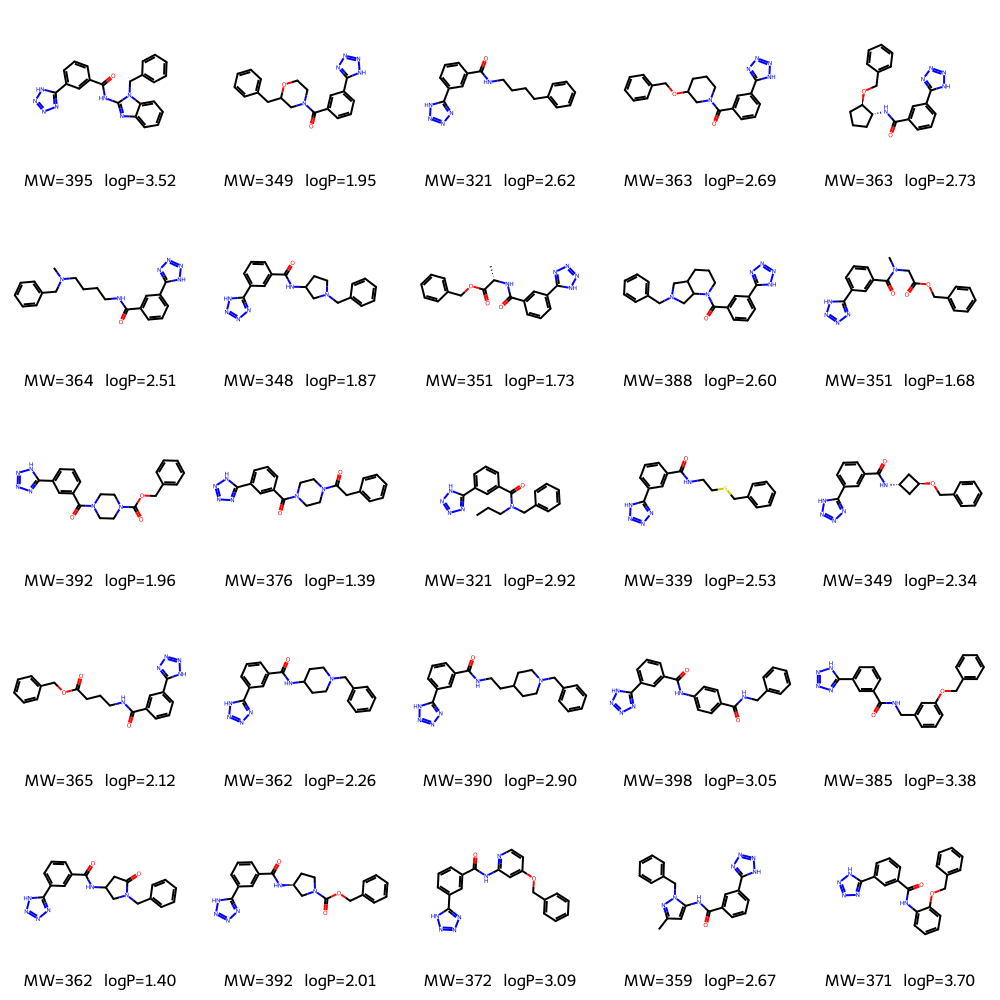

In [3]:
import random
from rdkit.Chem import Draw

random.seed(42)
sample = random.sample(rows, 25)
mols = [Chem.MolFromSmiles(r["smiles"]) for r in sample]
legends = [f"MW={r['mol_wt']:.0f}  logP={r['logp']:.2f}" for r in sample]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)